# Cache vs Prefetch Benchmark Plots

This notebook builds a benchmark-level speedup plot using:
- `results/cache_new_benchmarks.csv`
- `results/prefetch_new_benchmarks.csv`

For the prefetch data, the default behavior is to choose the **best IPC across all `min_layer_distance` values** for each `(benchmark, intermediate_capacity, eviction_policy)` pair, so each capacity gets exactly one prefetch `lru` bar and one prefetch `rri` bar.

In [2]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt


RESULTS_DIR = Path('/Users/gunagya/Desktop/Research Work/routing-space-sliding/simulators/routing-simulator/deps/quicksilver/results')
ROOT = RESULTS_DIR.parent
CACHE_CSV = RESULTS_DIR / 'cache_new_benchmarks.csv'
PREFETCH_CSV = RESULTS_DIR / 'prefetch_new_benchmarks.csv'


def load_rows(path):
    with open(path, newline='') as f:
        rows = list(csv.DictReader(f))
    return [
        row for row in rows
        if row.get('benchmark') not in (None, '', 'benchmark')
    ]


def to_float(value):
    if value in ('', None):
        return None
    return float(value)


def to_int(value):
    if value in ('', None):
        return None
    return int(float(value))


CACHE_ROWS = load_rows(CACHE_CSV)
PREFETCH_ROWS = load_rows(PREFETCH_CSV)
AVAILABLE_BENCHMARKS = sorted(set(row['benchmark'] for row in PREFETCH_ROWS))
AVAILABLE_BENCHMARKS


['bose_hubbard_q',
 'bose_hubbard_t',
 'chromium_q_prepare',
 'chromium_q_select',
 'chromium_t',
 'ethylene_oxide_q_prepare',
 'ethylene_oxide_q_select',
 'ethylene_oxide_t',
 'grover_3sat',
 'hc3h2cn_q_prepare',
 'hc3h2cn_q_select',
 'hc3h2cn_t',
 'manganese_nitride_q_prepare',
 'manganese_nitride_q_select',
 'manganese_nitride_t',
 'shor_rsa24']

In [82]:
def _pick_prefetch_rows(rows, selected_mld=None):
    grouped = defaultdict(list)
    for row in rows:
        if row['eviction_policy'] not in {'lru', 'rri'}:
            continue
        cap = to_int(row['intermediate_capacity'])
        mld = to_int(row['min_layer_distance'])
        if selected_mld is not None and mld != selected_mld:
            continue
        grouped[(cap, row['eviction_policy'])].append(row)

    chosen = {}
    for key, group in grouped.items():
        chosen[key] = max(group, key=lambda row: to_float(row['ipc']) or float('-inf'))
    return chosen


def _benchmark_plot_data(label, selected_mld=None):
    cache_rows = [row for row in CACHE_ROWS if row['benchmark'] == label]
    prefetch_rows = [row for row in PREFETCH_ROWS if row['benchmark'] == label]

    if not cache_rows and not prefetch_rows:
        raise ValueError(f'No rows found for benchmark: {label}')

    baseline_row = next((row for row in prefetch_rows if row['eviction_policy'] == 'eif'), None)
    baseline_ipc = to_float(baseline_row['ipc']) if baseline_row else None
    if baseline_ipc in (None, 0.0):
        raise ValueError(f'Could not determine a non-zero baseline IPC from prefetch CSV for {label}')

    ideal_row = next((row for row in prefetch_rows if row['eviction_policy'] == 'ideal_memory'), None)
    ideal_ipc = to_float(ideal_row['ipc']) if ideal_row else None
    ideal_speedup = (ideal_ipc / baseline_ipc) if ideal_ipc is not None else None

    cache_speedups = {}
    for row in cache_rows:
        policy = row['eviction_policy']
        if policy not in {'lru', 'rri'}:
            continue
        cap = to_int(row['intermediate_capacity'])
        ipc = to_float(row['ipc'])
        cache_speedups[(cap, policy)] = (ipc / baseline_ipc) if ipc is not None else None

    prefetch_choice = _pick_prefetch_rows(prefetch_rows, selected_mld=selected_mld)
    prefetch_speedups = {}
    prefetch_mlds = {}
    for key, row in prefetch_choice.items():
        ipc = to_float(row['ipc'])
        prefetch_speedups[key] = (ipc / baseline_ipc) if ipc is not None else None
        prefetch_mlds[key] = to_int(row['min_layer_distance'])

    capacities = sorted({cap for cap, _ in cache_speedups.keys()} | {cap for cap, _ in prefetch_speedups.keys()})
    if not capacities:
        raise ValueError(f'No capacity sweep rows available for {label}')

    return {
        'label': label,
        'baseline_ipc': baseline_ipc,
        'ideal_speedup': ideal_speedup,
        'cache_speedups': cache_speedups,
        'prefetch_speedups': prefetch_speedups,
        'prefetch_mlds': prefetch_mlds,
        'capacities': capacities,
    }


def _draw_benchmark_speedup_on_axis(ax, plot_data, selected_mld=None, annotate_prefetch_mld=True, show_ylabel=True):
    capacities = plot_data['capacities']
    cache_speedups = plot_data['cache_speedups']
    prefetch_speedups = plot_data['prefetch_speedups']
    prefetch_mlds = plot_data['prefetch_mlds']
    ideal_speedup = plot_data['ideal_speedup']
    label = plot_data['label']

    x = list(range(len(capacities)))
    width = 0.18
    offsets = {
        ('cache', 'lru'): -1.5 * width,
        ('cache', 'rri'): -0.5 * width,
        ('prefetch', 'lru'): 0.5 * width,
        ('prefetch', 'rri'): 1.5 * width,
    }
    colors = {
        ('cache', 'lru'): '#4C78A8',
        ('cache', 'rri'): '#72B7B2',
        ('prefetch', 'lru'): '#F58518',
        ('prefetch', 'rri'): '#E45756',
    }
    labels = {
        ('cache', 'lru'): 'Cache LRU',
        ('cache', 'rri'): 'Cache OPT',
        ('prefetch', 'lru'): 'Prefetch LRU',
        ('prefetch', 'rri'): 'Prefetch OPT',
    }

    legend_handles = {}

    def draw_series(kind, policy):
        heights = []
        positions = []
        cap_keys = []
        for idx, cap in enumerate(capacities):
            key = (cap, policy)
            value = cache_speedups.get(key) if kind == 'cache' else prefetch_speedups.get(key)
            if value is None:
                continue
            positions.append(x[idx] + offsets[(kind, policy)])
            heights.append(value)
            cap_keys.append(cap)

        bars = ax.bar(positions, heights, width=width, color=colors[(kind, policy)], label=labels[(kind, policy)])
        if len(bars) > 0:
            legend_handles[(kind, policy)] = bars

        if kind == 'prefetch' and annotate_prefetch_mld:
            for bar, cap in zip(bars, cap_keys):
                mld = prefetch_mlds.get((cap, policy))
                if mld is not None:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height(),
                        f'mld={mld}',
                        ha='center',
                        va='bottom',
                        fontsize=7,
                        rotation=90,
                    )

    draw_series('cache', 'lru')
    draw_series('cache', 'rri')
    draw_series('prefetch', 'lru')
    draw_series('prefetch', 'rri')

    if ideal_speedup is not None:
        line = ax.axhline(ideal_speedup, color='black', linestyle='--', linewidth=1.5, label='Ideal memory')
        legend_handles[('ideal', 'memory')] = line

    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    ax.set_xlabel('Intermediate capacity')
    if show_ylabel:
        ax.set_ylabel('Speedup over baseline')
    ax.set_title(label)
    ax.grid(axis='y', linestyle=':', alpha=0.35)
    ax.set_axisbelow(True)
    ax.margins(y=0.2)
    return legend_handles


def plot_benchmark_speedup(label, selected_mld=None, figsize=(12, 6), annotate_prefetch_mld=True):
    plot_data = _benchmark_plot_data(label, selected_mld=selected_mld)
    fig, ax = plt.subplots(figsize=figsize)
    legend_handles = _draw_benchmark_speedup_on_axis(
        ax,
        plot_data,
        selected_mld=selected_mld,
        annotate_prefetch_mld=annotate_prefetch_mld,
        show_ylabel=True,
    )

    title_suffix = 'best prefetch MLD per capacity/policy' if selected_mld is None else f'prefetch MLD={selected_mld}'
    ax.set_title(f'{label}: cache vs prefetch speedup ({title_suffix})')
    legend_order = [('cache', 'lru'), ('cache', 'rri'), ('prefetch', 'lru'), ('prefetch', 'rri'), ('ideal', 'memory')]
    ordered_handles = [legend_handles[key] for key in legend_order if key in legend_handles]
    ordered_labels = [
        'Cache LRU',
        'Cache OPT',
        'Prefetch LRU',
        'Prefetch OPT',
        'Ideal memory',
    ]
    ordered_labels = [label for key, label in zip(legend_order, ordered_labels) if key in legend_handles]
    ax.legend(handles=ordered_handles, labels=ordered_labels, ncols=3, frameon=False)
    plt.tight_layout()
    return fig, ax


def plot_all_benchmarks_speedup_grid(labels=None, selected_mld=None, ncols=3, figsize_per_panel=(5.2, 4.2), annotate_prefetch_mld=False):
    if labels is None:
        labels = AVAILABLE_BENCHMARKS
    labels = list(labels)
    if not labels:
        raise ValueError('No benchmark labels provided')

    plot_data_list = [_benchmark_plot_data(label, selected_mld=selected_mld) for label in labels]
    nrows = (len(labels) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        sharey=True,
    )

    if hasattr(axes, 'ravel'):
        axes = list(axes.ravel())
    else:
        axes = [axes]

    all_legend_handles = {}
    for idx, (ax, plot_data) in enumerate(zip(axes, plot_data_list)):
        handles = _draw_benchmark_speedup_on_axis(
            ax,
            plot_data,
            selected_mld=selected_mld,
            annotate_prefetch_mld=annotate_prefetch_mld,
            show_ylabel=(idx % ncols == 0),
        )
        all_legend_handles.update(handles)

    for ax in axes[len(plot_data_list):]:
        ax.axis('off')

    title_suffix = 'best prefetch MLD per capacity/policy' if selected_mld is None else f'prefetch MLD={selected_mld}'
    fig.suptitle(f'Cache vs prefetch speedup across benchmarks ({title_suffix})', y=0.995)

    legend_order = [('cache', 'lru'), ('cache', 'rri'), ('prefetch', 'lru'), ('prefetch', 'rri'), ('ideal', 'memory')]
    ordered_handles = [all_legend_handles[key] for key in legend_order if key in all_legend_handles]
    ordered_labels = [
        'Cache LRU',
        'Cache OPT',
        'Prefetch LRU',
        'Prefetch OPT',
        'Ideal memory',
    ]
    ordered_labels = [label for key, label in zip(legend_order, ordered_labels) if key in all_legend_handles]
    fig.legend(handles=ordered_handles, labels=ordered_labels, loc='upper center', ncols=5, frameon=False, bbox_to_anchor=(0.5, 0.965))
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    return fig, axes


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'shor_rsa24: cache vs prefetch speedup (best prefetch MLD per capacity/policy)'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>)

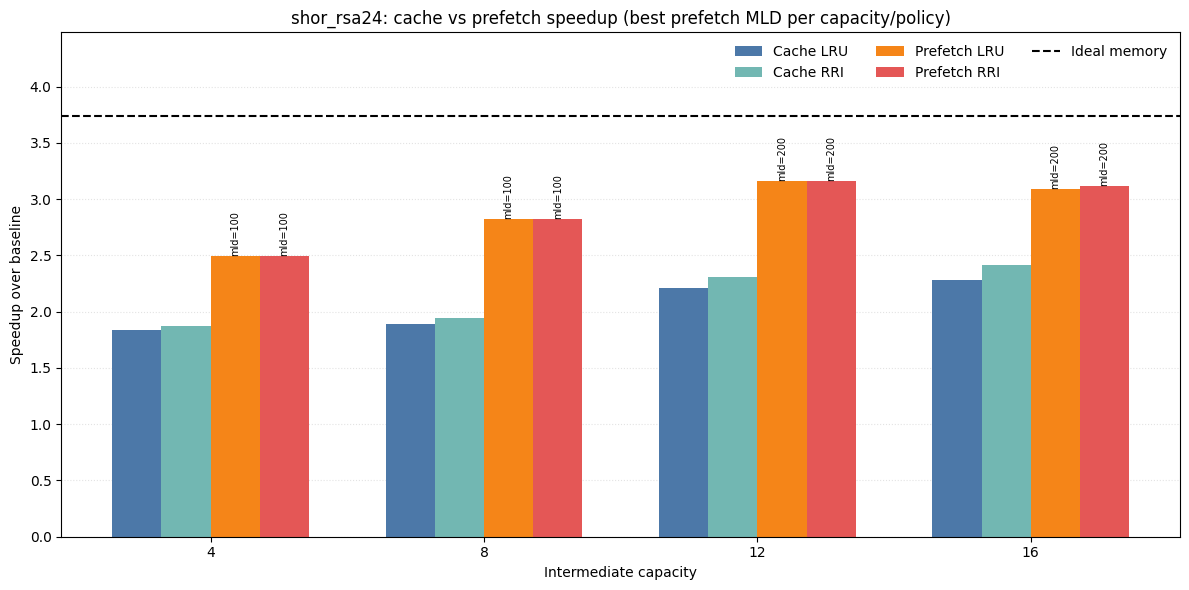

In [83]:
BENCHMARK = 'shor_rsa24'
plot_benchmark_speedup(BENCHMARK)
# Example for a fixed prefetch MLD instead of best-per-capacity:
# plot_benchmark_speedup(BENCHMARK, selected_mld=125)


(<Figure size 1560x2520 with 18 Axes>,
 [<Axes: title={'center': 'bose_hubbard_q'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>,
  <Axes: title={'center': 'bose_hubbard_t'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'chromium_q_prepare'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'chromium_q_select'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>,
  <Axes: title={'center': 'chromium_t'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'ethylene_oxide_q_prepare'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'ethylene_oxide_q_select'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>,
  <Axes: title={'center': 'ethylene_oxide_t'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'grover_3sat'}, xlabel='Intermediate capacity'>,
  <Axes: title={'center': 'hc3h2cn_q_prepare'}, xlabel='Intermediate capacity', ylabel='Speedup over baseline'>,
  <Axes: title={'center': 'hc

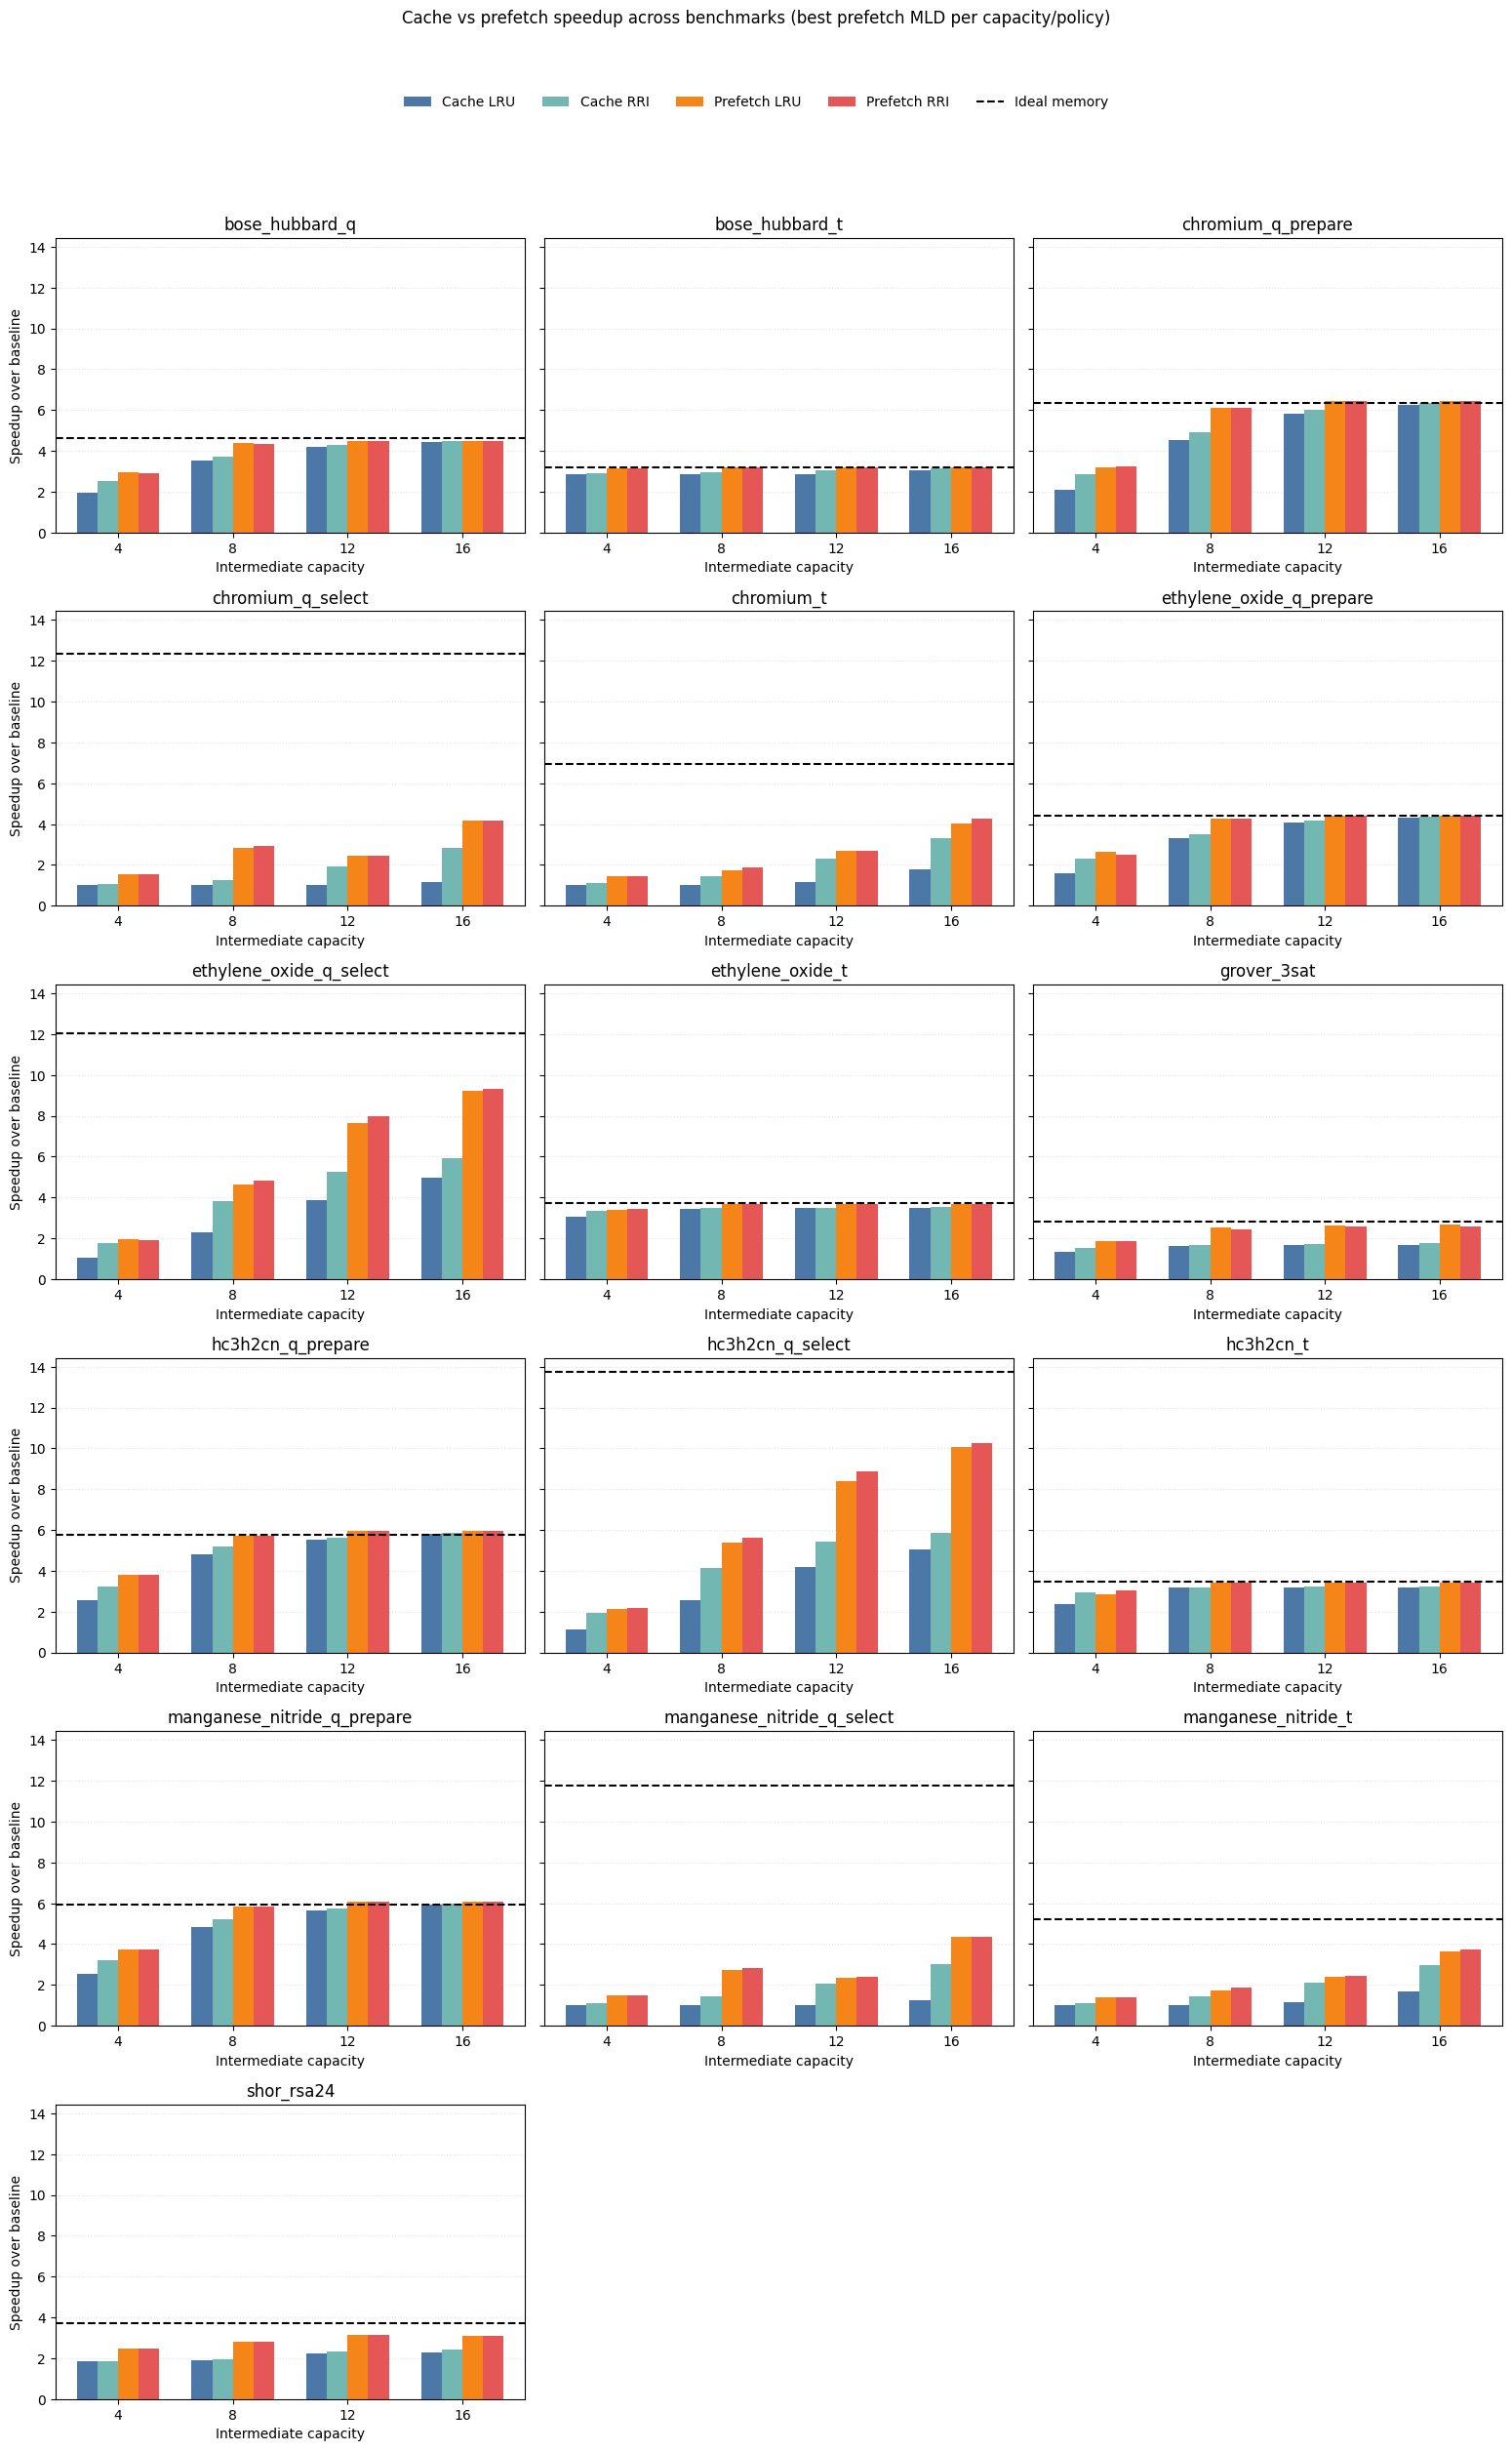

In [84]:
plot_all_benchmarks_speedup_grid()
# Example with a fixed prefetch MLD:
# plot_all_benchmarks_speedup_grid(selected_mld=125)


In [6]:
import math

def geometric_mean(values):
    values = [value for value in values if value is not None and value > 0]
    if not values:
        return None
    return math.exp(sum(math.log(value) for value in values) / len(values))


def speedup_gmean_by_approach_at_capacity(selected_capacity=8, labels=None, selected_mld=None, include_ideal_memory=True):
    if labels is None:
        labels = AVAILABLE_BENCHMARKS

    labels = list(labels)
    approach_values = {
        'cache_lru': [],
        'cache_rri': [],
        'prefetch_lru': [],
        'prefetch_rri': [],
    }
    if include_ideal_memory:
        approach_values['ideal_memory'] = []

    per_benchmark = {}
    for label in labels:
        plot_data = _benchmark_plot_data(label, selected_mld=selected_mld)

        benchmark_values = {
            'cache_lru': plot_data['cache_speedups'].get((selected_capacity, 'lru')),
            'cache_rri': plot_data['cache_speedups'].get((selected_capacity, 'rri')),
            'prefetch_lru': plot_data['prefetch_speedups'].get((selected_capacity, 'lru')),
            'prefetch_rri': plot_data['prefetch_speedups'].get((selected_capacity, 'rri')),
        }
        if include_ideal_memory:
            benchmark_values['ideal_memory'] = plot_data['ideal_speedup']

        per_benchmark[label] = benchmark_values

        for approach, value in benchmark_values.items():
            if value is not None:
                approach_values[approach].append(value)

    gmeans = {approach: geometric_mean(values) for approach, values in approach_values.items()}
    return {
        'selected_capacity': selected_capacity,
        'per_benchmark_speedups': per_benchmark,
        'gmean_of_speedups': gmeans,
    }


gmean_summary = speedup_gmean_by_approach_at_capacity(selected_capacity=8)
gmean_summary['gmean_of_speedups']


NameError: name '_benchmark_plot_data' is not defined

In [9]:
def _constraint_sort_key(label):
    return int(label)

def plot_optimize_memory_config_sweep(csv_path=None, figsize=(10, 6)):
    if csv_path is None:
        candidates = [
            ROOT / 'build' / 'optimize_memory_config_sweep.csv',
            ROOT.parent / 'build' / 'optimize_memory_config_sweep.csv',
            ROOT / 'optimize_memory_config_sweep.csv',
            ROOT.parent / 'optimize_memory_config_sweep.csv',
            RESULTS_DIR / 'optimize_memory_config_sweep.csv',
            RESULTS_DIR.parent / 'build' / 'optimize_memory_config_sweep.csv',
        ]
        candidates = list(dict.fromkeys(candidates))
        csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if csv_path is None:
            searched = '\n'.join(str(candidate) for candidate in candidates)
            raise FileNotFoundError(
                'Could not find optimize_memory_config_sweep.csv. Searched:\n' + searched
            )
    else:
        csv_path = Path(csv_path)

    with open(csv_path, newline='') as f:
        rows = list(csv.DictReader(f))
    grouped = defaultdict(list)
    for row in rows:
        logical_qubits = to_int(row['logical_qubits'])
        physical_qubits = to_int(row['physical_qubits'])
        constraint = row['min_1d_size']
        if logical_qubits is None or physical_qubits is None:
            continue
        grouped[constraint].append((logical_qubits, physical_qubits))

    if not grouped:
        raise ValueError(f'No valid rows found in {csv_path}')

    fig, ax = plt.subplots(figsize=figsize)
    color_map = {
        '0': '#222222',
        '4': '#4C78A8',
        '8': '#72B7B2',
        '16': '#F58518',
        '24': '#E45756',
        '32': '#54A24B',
    }

    for constraint in sorted(grouped.keys(), key=_constraint_sort_key):
        series = sorted(grouped[constraint], key=lambda pair: pair[0])
        x = [pair[0] for pair in series]
        y = [pair[1] for pair in series]
        label = 'Min 1D size = 0' if constraint == '0' else f'Min 1D size = {constraint}'
        ax.plot(x, y, marker='o', markersize=3, linewidth=2, label=label, color=color_map.get(constraint))

    ax.set_xlabel('Logical qubits in memory')
    ax.set_ylabel('Physical qubit count')
    ax.set_title('Optimal memory configuration sweep')
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncols=2)
    ax.margins(x=0.02, y=0.08)
    plt.tight_layout()
    return fig, ax

plot_optimize_memory_config_sweep()


ValueError: No valid rows found in /Users/gunagya/Desktop/Research Work/routing-space-sliding/simulators/routing-simulator/deps/quicksilver/build/optimize_memory_config_sweep.csv

{'min_1d_size=4': 2656.5364431486882,
 'min_1d_size=8': 4383.50687213661,
 'min_1d_size=16': 7787.102040816327,
 'min_1d_size=24': 11190.697209496044,
 'min_1d_size=32': 14613.35110370679}

GMean speedups: {'Cache LRU': 2.3385, 'Cache OPT': 2.6965, 'Prefetch LRU': 4.0975, 'Prefetch OPT': 3.8891, 'Ideal memory': 5.4292}


(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'Cache vs prefetch relative speedups at intermediate capacity 8'}, xlabel='Benchmark', ylabel='Relative speedup over baseline'>)

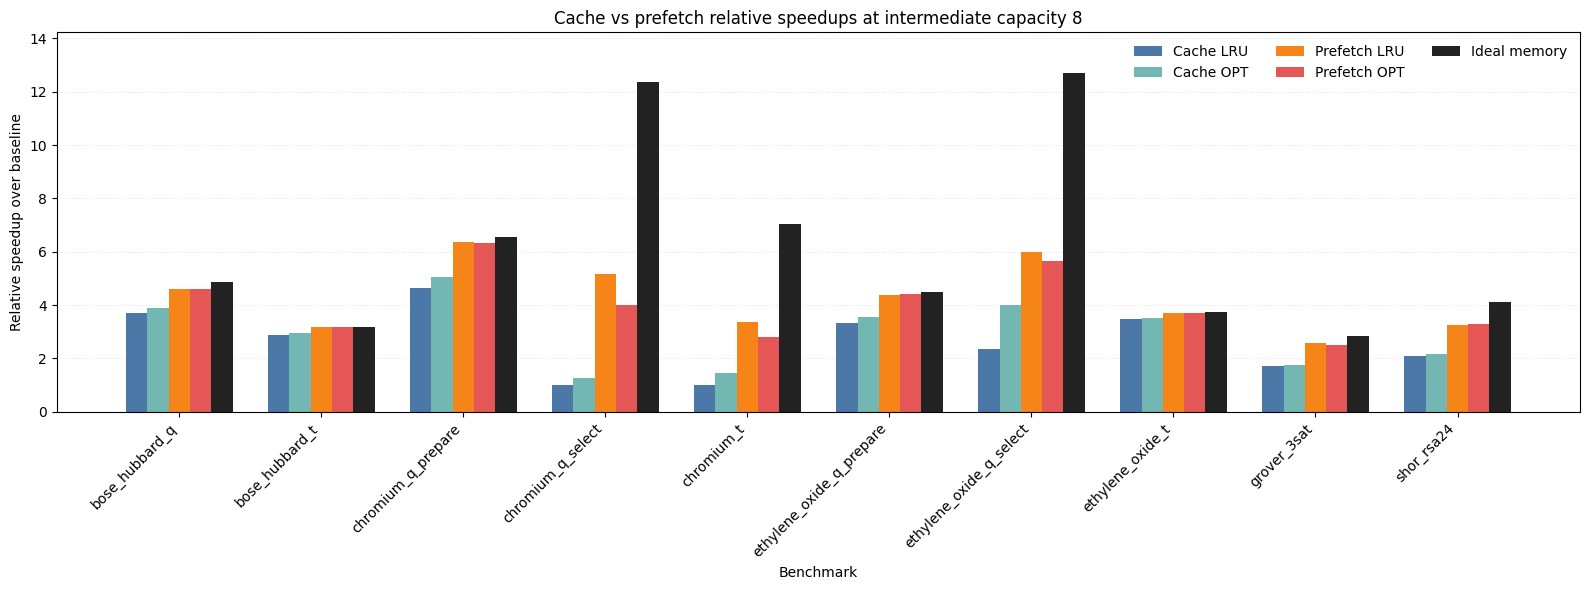

In [18]:
def plot_i8_cache_prefetch_relative_speedups(
    cache_csv=None,
    prefetch_csv=None,
    selected_mld=None,
    figsize=(16, 6),
):
    if cache_csv is None:
        cache_candidates = [
            RESULTS_DIR / 'cache_new_benchmarks_i8.csv',
            ROOT / 'results' / 'cache_new_benchmarks_i8.csv',
            ROOT / 'cache_new_benchmarks_i8.csv',
        ]
        cache_csv = next((candidate for candidate in cache_candidates if candidate.exists()), None)
        if cache_csv is None:
            raise FileNotFoundError('Could not find cache_new_benchmarks_i8.csv')
    else:
        cache_csv = Path(cache_csv)

    if prefetch_csv is None:
        prefetch_candidates = [
            RESULTS_DIR / 'prefetch_new_benchmarks_i8.csv',
            ROOT / 'results' / 'prefetch_new_benchmarks_i8.csv',
            ROOT / 'prefetch_new_benchmarks_i8.csv',
        ]
        prefetch_csv = next((candidate for candidate in prefetch_candidates if candidate.exists()), None)
        if prefetch_csv is None:
            raise FileNotFoundError('Could not find prefetch_new_benchmarks_i8.csv')
    else:
        prefetch_csv = Path(prefetch_csv)

    cache_rows = load_rows(cache_csv)
    prefetch_rows = load_rows(prefetch_csv)

    benchmarks = sorted(set(row['benchmark'] for row in cache_rows) | set(row['benchmark'] for row in prefetch_rows))
    approaches = ['cache_lru', 'cache_rri', 'prefetch_lru', 'prefetch_rri', 'ideal_memory']
    display_labels = {
        'cache_lru': 'Cache LRU',
        'cache_rri': 'Cache OPT',
        'prefetch_lru': 'Prefetch LRU',
        'prefetch_rri': 'Prefetch OPT',
        'ideal_memory': 'Ideal memory',
    }
    colors = {
        'cache_lru': '#4C78A8',
        'cache_rri': '#72B7B2',
        'prefetch_lru': '#F58518',
        'prefetch_rri': '#E45756',
        'ideal_memory': '#222222',
    }

    speedups = {approach: [] for approach in approaches}

    for benchmark in benchmarks:
        cache_benchmark_rows = [row for row in cache_rows if row['benchmark'] == benchmark]
        prefetch_benchmark_rows = [row for row in prefetch_rows if row['benchmark'] == benchmark]

        baseline_row = next((row for row in prefetch_benchmark_rows if row['eviction_policy'] == 'eif'), None)
        baseline_ipc = to_float(baseline_row['ipc']) if baseline_row else None
        if baseline_ipc in (None, 0.0):
            raise ValueError(f'Could not determine baseline IPC from prefetch CSV for {benchmark}')

        cache_lru_row = next((row for row in cache_benchmark_rows if row['eviction_policy'] == 'lru'), None)
        cache_rri_row = next((row for row in cache_benchmark_rows if row['eviction_policy'] == 'rri'), None)

        prefetch_candidates = [
            row for row in prefetch_benchmark_rows
            if row['eviction_policy'] in {'lru', 'rri'} and to_int(row['intermediate_capacity']) == 8
        ]
        if selected_mld is not None:
            prefetch_candidates = [row for row in prefetch_candidates if to_int(row['min_layer_distance']) == selected_mld]

        prefetch_best = {}
        for policy in ['lru', 'rri']:
            rows_for_policy = [row for row in prefetch_candidates if row['eviction_policy'] == policy]
            prefetch_best[policy] = max(rows_for_policy, key=lambda row: to_float(row['ipc']) or float('-inf')) if rows_for_policy else None

        ideal_row = next((row for row in prefetch_benchmark_rows if row['eviction_policy'] == 'ideal_memory'), None)

        lookup = {
            'cache_lru': cache_lru_row,
            'cache_rri': cache_rri_row,
            'prefetch_lru': prefetch_best['lru'],
            'prefetch_rri': prefetch_best['rri'],
            'ideal_memory': ideal_row,
        }

        for approach in approaches:
            row = lookup[approach]
            ipc = to_float(row['ipc']) if row else None
            speedups[approach].append((ipc / baseline_ipc) if ipc is not None else None)

    fig, ax = plt.subplots(figsize=figsize)
    x = list(range(len(benchmarks)))
    width = 0.15
    offsets = {
        'cache_lru': -2 * width,
        'cache_rri': -1 * width,
        'prefetch_lru': 0,
        'prefetch_rri': 1 * width,
        'ideal_memory': 2 * width,
    }

    for approach in approaches:
        positions = [value + offsets[approach] for value in x]
        heights = [0 if value is None else value for value in speedups[approach]]
        ax.bar(positions, heights, width=width, label=display_labels[approach], color=colors[approach])

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks, rotation=45, ha='right')
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Relative speedup over baseline')
    title_suffix = 'best prefetch MLD per benchmark' if selected_mld is None else f'prefetch MLD={selected_mld}'
    ax.set_title(f'Cache vs prefetch relative speedups at intermediate capacity 8')
    ax.grid(axis='y', linestyle=':', alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncols=3)
    ax.margins(y=0.12)

    gmeans = {
        display_labels[approach]: geometric_mean(speedups[approach])
        for approach in approaches
    }
    print('GMean speedups:', {key: (round(value, 4) if value is not None else None) for key, value in gmeans.items()})

    plt.tight_layout()
    return fig, ax

plot_i8_cache_prefetch_relative_speedups()
# Example with a fixed prefetch MLD:
# plot_i8_cache_prefetch_relative_speedups(selected_mld=100)


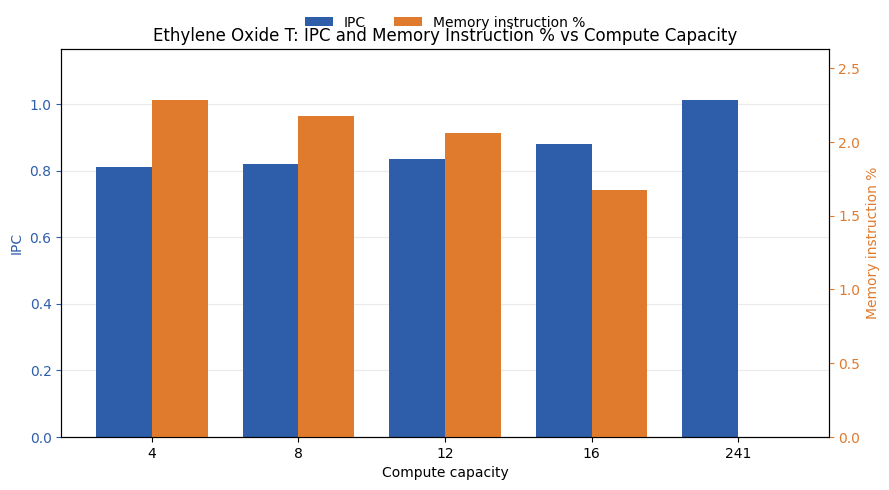

In [49]:
def plot_ethylene_oxide_t_capacity_sweep(csv_path=None, figsize=(9, 5)):
    if csv_path is None:
        candidates = [
            ROOT / 'build' / 'ethylene_oxide_t_capacity_sweep.csv',
            ROOT / 'ethylene_oxide_t_capacity_sweep.csv',
            RESULTS_DIR / 'ethylene_oxide_t_capacity_sweep.csv',
            RESULTS_DIR.parent / 'build' / 'ethylene_oxide_t_capacity_sweep.csv',
        ]
        csv_path = next((path for path in candidates if path.exists()), None)
        if csv_path is None:
            raise FileNotFoundError('Could not find ethylene_oxide_t_capacity_sweep.csv')

    rows = load_rows(csv_path)
    rows = sorted(rows, key=lambda row: to_int(row['compute_capacity']) or 0)

    capacities = [to_int(row['compute_capacity']) for row in rows]
    ipc_values = [to_float(row['ipc']) for row in rows]
    mem_pct_values = [to_float(row['memory_instruction_percentage']) for row in rows]

    x = list(range(len(capacities)))
    width = 0.38

    fig, ax_ipc = plt.subplots(figsize=figsize)
    ax_mem = ax_ipc.twinx()

    ipc_bars = ax_ipc.bar(
        [xi - width / 2 for xi in x],
        ipc_values,
        width=width,
        color='#2E5EAA',
        label='IPC',
    )
    mem_bars = ax_mem.bar(
        [xi + width / 2 for xi in x],
        mem_pct_values,
        width=width,
        color='#E07A2D',
        label='Memory instruction %',
    )

    ax_ipc.set_xticks(x)
    ax_ipc.set_xticklabels([str(cap) for cap in capacities])
    ax_ipc.set_xlabel('Compute capacity')
    ax_ipc.set_ylabel('IPC', color='#2E5EAA')
    ax_mem.set_ylabel('Memory instruction %', color='#E07A2D')
    ax_ipc.tick_params(axis='y', colors='#2E5EAA')
    ax_mem.tick_params(axis='y', colors='#E07A2D')
    ax_ipc.set_title('Ethylene Oxide T: IPC and Memory Instruction % vs Compute Capacity')
    ax_ipc.grid(axis='y', alpha=0.25)
    ax_ipc.set_axisbelow(True)
    ax_ipc.margins(y=0.15)
    ax_mem.margins(y=0.15)

    handles = [ipc_bars, mem_bars]
    labels = ['IPC', 'Memory instruction %']
    ax_ipc.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)

    plt.tight_layout()
    plt.show()


plot_ethylene_oxide_t_capacity_sweep()


In [68]:
def plot_selected_benchmarks_i8_speedups(
    benchmarks,
    cache_csv=None,
    prefetch_csv=None,
    figsize=(14, 6),
):
    if cache_csv is None:
        cache_candidates = [
            RESULTS_DIR / 'cache_new_benchmarks.csv',
            ROOT / 'results' / 'cache_new_benchmarks.csv',
            ROOT / 'cache_new_benchmarks.csv',
        ]
        cache_csv = next((candidate for candidate in cache_candidates if candidate.exists()), None)
        if cache_csv is None:
            raise FileNotFoundError('Could not find cache_new_benchmarks.csv')
    else:
        cache_csv = Path(cache_csv)

    if prefetch_csv is None:
        prefetch_candidates = [
            RESULTS_DIR / 'prefetch_new_benchmarks.csv',
            ROOT / 'results' / 'prefetch_new_benchmarks.csv',
            ROOT / 'prefetch_new_benchmarks.csv',
        ]
        prefetch_csv = next((candidate for candidate in prefetch_candidates if candidate.exists()), None)
        if prefetch_csv is None:
            raise FileNotFoundError('Could not find prefetch_new_benchmarks.csv')
    else:
        prefetch_csv = Path(prefetch_csv)

    cache_rows = load_rows(cache_csv)
    prefetch_rows = load_rows(prefetch_csv)

    selected_benchmarks = list(benchmarks)
    approaches = ['cache_lru', 'cache_rri', 'prefetch_lru', 'prefetch_rri', 'ideal_memory']
    display_labels = {
        'cache_lru': 'Cache LRU',
        'cache_rri': 'Cache OPT',
        'prefetch_lru': 'Prefetch LRU',
        'prefetch_rri': 'Prefetch OPT',
        'ideal_memory': 'Ideal memory',
    }
    colors = {
        'cache_lru': '#4C78A8',
        'cache_rri': '#72B7B2',
        'prefetch_lru': '#F58518',
        'prefetch_rri': '#E45756',
        'ideal_memory': '#222222',
    }

    def row_capacity(row):
        return to_int(row.get('intermediate_capacity'))

    def row_ipc(row):
        return to_float(row.get('ipc'))

    speedups = {approach: [] for approach in approaches}

    for benchmark in selected_benchmarks:
        cache_benchmark_rows = [row for row in cache_rows if row.get('benchmark') == benchmark]
        prefetch_benchmark_rows = [row for row in prefetch_rows if row.get('benchmark') == benchmark]

        if not cache_benchmark_rows and not prefetch_benchmark_rows:
            raise ValueError(f'Benchmark {benchmark!r} not found in either CSV')

        cache_baseline = next((row for row in cache_benchmark_rows if row.get('eviction_policy') == 'eif_baseline'), None)
        prefetch_baseline = next((row for row in prefetch_benchmark_rows if row.get('eviction_policy') == 'eif'), None)
        baseline_row = cache_baseline or prefetch_baseline
        baseline_ipc = row_ipc(baseline_row) if baseline_row else None
        if baseline_ipc in (None, 0.0):
            raise ValueError(f'Could not determine baseline IPC for {benchmark}')

        cache_lru_row = next(
            (row for row in cache_benchmark_rows if row.get('eviction_policy') == 'lru' and row_capacity(row) == 8),
            None,
        )
        cache_rri_row = next(
            (row for row in cache_benchmark_rows if row.get('eviction_policy') == 'rri' and row_capacity(row) == 8),
            None,
        )

        prefetch_i8_rows = [
            row for row in prefetch_benchmark_rows
            if row.get('eviction_policy') in {'lru', 'rri'} and row_capacity(row) == 8
        ]
        prefetch_best = {}
        for policy in ['lru', 'rri']:
            rows_for_policy = [row for row in prefetch_i8_rows if row.get('eviction_policy') == policy]
            prefetch_best[policy] = max(
                rows_for_policy,
                key=lambda row: row_ipc(row) if row_ipc(row) is not None else float('-inf'),
            ) if rows_for_policy else None

        ideal_row = next((row for row in prefetch_benchmark_rows if row.get('eviction_policy') == 'ideal_memory'), None)

        lookup = {
            'cache_lru': cache_lru_row,
            'cache_rri': cache_rri_row,
            'prefetch_lru': prefetch_best['lru'],
            'prefetch_rri': prefetch_best['rri'],
            'ideal_memory': ideal_row,
        }

        for approach in approaches:
            row = lookup[approach]
            ipc = row_ipc(row) if row else None
            speedups[approach].append((ipc / baseline_ipc) if ipc is not None else None)

    fig, ax = plt.subplots(figsize=figsize)
    x = list(range(len(selected_benchmarks)))
    width = 0.15
    offsets = {
        'cache_lru': -2 * width,
        'cache_rri': -1 * width,
        'prefetch_lru': 0,
        'prefetch_rri': 1 * width,
        'ideal_memory': 2 * width,
    }

    for approach in approaches:
        positions = [value + offsets[approach] for value in x]
        heights = [0 if value is None else value for value in speedups[approach]]
        ax.bar(positions, heights, width=width, label=display_labels[approach], color=colors[approach])

    ax.set_xticks(x)
    ax.set_xticklabels(selected_benchmarks, rotation=45, ha='right')
    ax.set_xlabel('Benchmark')
    ax.set_ylabel('Relative speedup over baseline')
    ax.set_title('Selected benchmarks: speedups at intermediate capacity 8')
    ax.grid(axis='y', linestyle=':', alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncols=3)
    ax.margins(y=0.12)
    plt.tight_layout()
    return fig, ax


plot_selected_benchmarks_i8_speedups([
    'bose_hubbard_t',
    'ethylene_oxide_q',
    'ethylene_oxide_t',
    'hc3h2cn_q',
    'hc3h2cn_t',
    'chromium_q',
    'manganese_nitride_q',
])


ValueError: Could not determine baseline IPC from prefetch CSV for ethylene_oxide_q

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: xlabel='Benchmark', ylabel='Speedup over baseline'>,
  <Axes: ylabel='Compile median timeliness (cycles)'>))

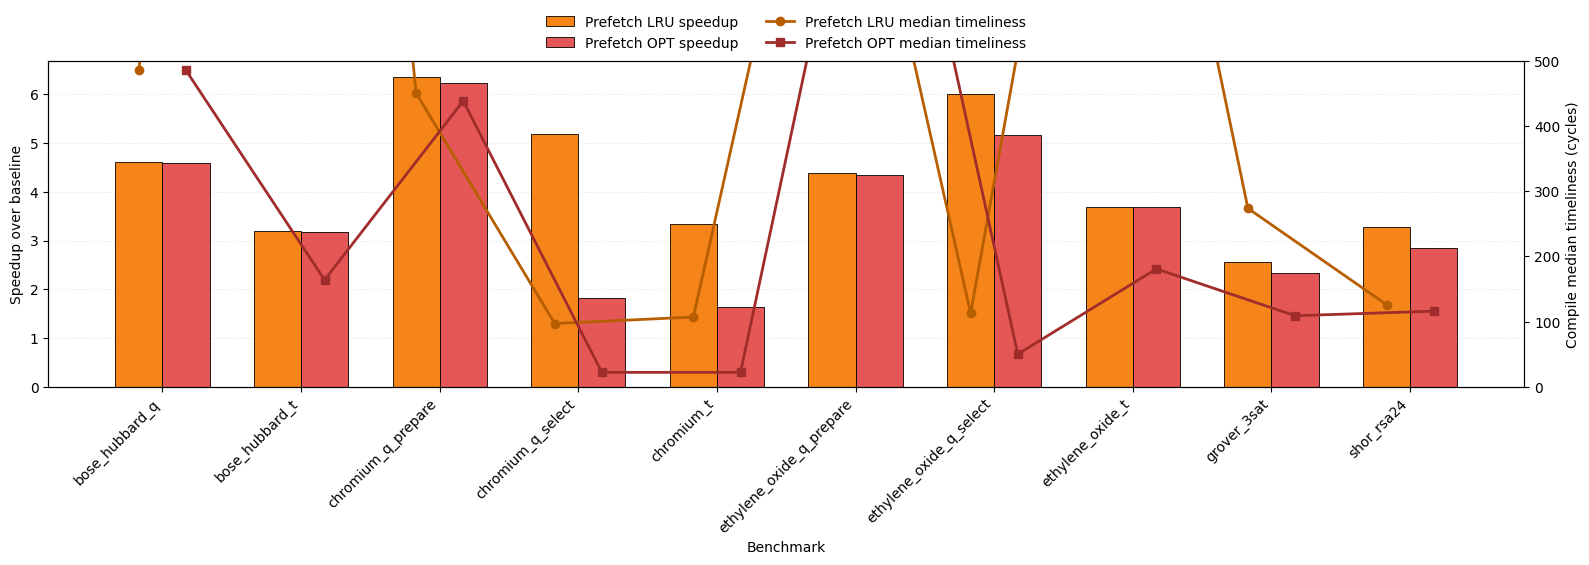

In [6]:
def plot_i8_prefetch_speedup_and_candidate_distance_at_mld_zero(csv_path=None, figsize=(16, 6)):
    if csv_path is None:
        candidates = [
            RESULTS_DIR / 'prefetch_new_benchmarks_i8.csv',
            ROOT / 'results' / 'prefetch_new_benchmarks_i8.csv',
            ROOT / 'prefetch_new_benchmarks_i8.csv',
        ]
        csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if csv_path is None:
            raise FileNotFoundError('Could not find prefetch_new_benchmarks_i8.csv')
    else:
        csv_path = Path(csv_path)

    rows = load_rows(csv_path)
    filtered_rows = [
        row for row in rows
        if row.get('eviction_policy') in {'lru', 'rri'}
        and to_int(row.get('intermediate_capacity')) == 8
        and to_int(row.get('min_layer_distance')) == 0
    ]
    if not filtered_rows:
        raise ValueError('No intermediate_capacity=8, min_layer_distance=0 prefetch rows found')

    benchmarks = sorted(set(row['benchmark'] for row in filtered_rows))
    baseline_rows = {
        row['benchmark']: row
        for row in rows
        if row.get('eviction_policy') == 'eif'
    }
    policy_rows = {
        (row['benchmark'], row['eviction_policy']): row
        for row in filtered_rows
    }

    speedup_values = {'lru': [], 'rri': []}
    median_candidate_distance = {
        'lru': [to_float(policy_rows.get((benchmark, 'lru'), {}).get('compile_median_candidate_distance')) for benchmark in benchmarks],
        'rri': [to_float(policy_rows.get((benchmark, 'rri'), {}).get('compile_median_candidate_distance')) for benchmark in benchmarks],
    }

    for benchmark in benchmarks:
        baseline_row = baseline_rows.get(benchmark)
        baseline_ipc = to_float(baseline_row.get('ipc')) if baseline_row else None
        if baseline_ipc in (None, 0.0):
            raise ValueError(f'Could not determine baseline IPC from eif row for {benchmark}')

        for policy in ['lru', 'rri']:
            row = policy_rows.get((benchmark, policy))
            ipc = to_float(row.get('ipc')) if row else None
            speedup_values[policy].append(None if ipc is None else ipc / baseline_ipc)

    fig, ax_ipc = plt.subplots(figsize=figsize)
    ax_distance = ax_ipc.twinx()

    x = list(range(len(benchmarks)))
    width = 0.34
    bar_positions = {
        'lru': [value - width / 2 for value in x],
        'rri': [value + width / 2 for value in x],
    }

    bar_colors = {
        'lru': '#F58518',
        'rri': '#E45756',
    }
    line_colors = {
        'lru': '#B65E00',
        'rri': '#A02C2C',
    }

    lru_bars = ax_ipc.bar(
        bar_positions['lru'],
        [float('nan') if value is None else value for value in speedup_values['lru']],
        width=width,
        color=bar_colors['lru'],
        label='Prefetch LRU speedup',
        edgecolor='k',
        linewidth=0.6,
    )
    rri_bars = ax_ipc.bar(
        bar_positions['rri'],
        [float('nan') if value is None else value for value in speedup_values['rri']],
        width=width,
        color=bar_colors['rri'],
        label='Prefetch OPT speedup',
        edgecolor='k',
        linewidth=0.6,
    )

    lru_line, = ax_distance.plot(
        bar_positions['lru'],
        [float('nan') if value is None else value for value in median_candidate_distance['lru']],
        color=line_colors['lru'],
        marker='o',
        linewidth=2,
        label='Prefetch LRU median timeliness',
    )
    rri_line, = ax_distance.plot(
        bar_positions['rri'],
        [float('nan') if value is None else value for value in median_candidate_distance['rri']],
        color=line_colors['rri'],
        marker='s',
        linewidth=2,
        label='Prefetch OPT median timeliness',
    )

    ax_ipc.set_xticks(x)
    ax_ipc.set_xticklabels(benchmarks, rotation=45, ha='right')
    ax_ipc.set_xlabel('Benchmark')
    ax_ipc.set_ylabel('Speedup over baseline')
    ax_distance.set_ylabel('Compile median timeliness (cycles)')
    ax_distance.set_ylim(0, 500)
    ax_ipc.grid(axis='y', linestyle=':', alpha=0.35)
    ax_ipc.set_axisbelow(True)

    handles = [lru_bars, rri_bars, lru_line, rri_line]
    labels = [handle.get_label() for handle in handles]
    ax_ipc.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, frameon=False)
    plt.tight_layout()
    return fig, (ax_ipc, ax_distance)


plot_i8_prefetch_speedup_and_candidate_distance_at_mld_zero()


In [17]:
import re
import subprocess
import pandas as pd


def optimize_memory_config_physical_qubit_table(qubit_counts=None, error_rate=3e-15):
    if qubit_counts is None:
        qubit_counts = [2224, 163, 285, 2184, 117, 237, 108, 1706]

    executable_candidates = [
        ROOT / 'build' / 'optimize_memory_config',
        RESULTS_DIR.parent / 'build' / 'optimize_memory_config',
        Path('build/optimize_memory_config'),
    ]
    executable = next((candidate for candidate in executable_candidates if candidate.exists()), None)
    if executable is None:
        raise FileNotFoundError('Could not find build/optimize_memory_config')

    configurations = [
        ('optimal', []),
        ('min_1d_size_8', ['--min-1d-size', '8']),
        ('only_2d', ['--only-2d']),
    ]

    total_physical_qubits = {label: [] for label, _ in configurations}
    physical_qubits_pattern = re.compile(r'^Total physical qubits:\s*(\d+)\s*$')

    for logical_qubits in qubit_counts:
        for label, extra_args in configurations:
            command = [
                str(executable),
                '--max-2d-grid-length', '24',
                *extra_args,
                str(error_rate),
                str(logical_qubits),
            ]
            completed = subprocess.run(command, capture_output=True, text=True, check=True)

            match = None
            for line in completed.stdout.splitlines():
                current_match = physical_qubits_pattern.match(line.strip())
                if current_match is not None:
                    match = current_match

            if match is None:
                raise ValueError(
                    f'Could not parse total physical qubits for {label} at logical qubits={logical_qubits}\n'
                    f'Command: {" ".join(command)}\n\n{completed.stdout}'
                )

            total_physical_qubits[label].append(int(match.group(1)))

    rows = []
    for idx, logical_qubits in enumerate(qubit_counts):
        optimal = total_physical_qubits['optimal'][idx]
        min_1d_size_8 = total_physical_qubits['min_1d_size_8'][idx]
        only_2d = total_physical_qubits['only_2d'][idx]
        rows.append({
            'memory_logical_qubits': logical_qubits,
            'optimal_physical_qubits': optimal,
            'min_1d_size_8_physical_qubits': min_1d_size_8,
            'only_2d_physical_qubits': only_2d,
            'min_1d_size_8_minus_optimal': min_1d_size_8 - optimal,
            'min_1d_size_8_overhead_percent': 100.0 * (min_1d_size_8 - optimal) / optimal,
            'only_2d_minus_optimal': only_2d - optimal,
        })

    return pd.DataFrame(rows)


optimize_memory_config_physical_qubit_table()


,memory_logical_qubits,optimal_physical_qubits,min_1d_size_8_physical_qubits,only_2d_physical_qubits,min_1d_size_8_minus_optimal,min_1d_size_8_overhead_percent,only_2d_minus_optimal
0,2224,1022640,1031440,1022640,8800,0.860518,0
1,163,88084,96884,88084,8800,9.990464,0
2,285,141800,150600,141800,8800,6.205924,0
3,2184,1012560,1012560,1022640,0,0.000000,10080
4,117,73076,73076,81512,0,0.000000,8436
5,237,126440,126440,141800,0,0.000000,15360
6,108,64276,64276,81512,0,0.000000,17236
7,1706,792756,801556,792756,8800,1.110052,0


In [16]:
def average_min_1d_absolute_overhead_vs_only_2d(csv_path=None):
    if csv_path is None:
        candidates = [
            ROOT / 'build' / 'optimize_memory_config_sweep.csv',
            ROOT.parent / 'build' / 'optimize_memory_config_sweep.csv',
            ROOT / 'optimize_memory_config_sweep.csv',
            ROOT.parent / 'optimize_memory_config_sweep.csv',
            RESULTS_DIR / 'optimize_memory_config_sweep.csv',
            RESULTS_DIR.parent / 'build' / 'optimize_memory_config_sweep.csv',
        ]
        candidates = list(dict.fromkeys(candidates))
        csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if csv_path is None:
            searched = '\n'.join(str(candidate) for candidate in candidates)
            raise FileNotFoundError('Could not find optimize_memory_config_sweep.csv. Searched:\n' + searched)
    else:
        csv_path = Path(csv_path)

    with open(csv_path, newline='') as f:
        rows = list(csv.DictReader(f))
    by_constraint = defaultdict(dict)
    for row in rows:
        logical_qubits = to_int(row['logical_qubits'])
        physical_qubits = to_float(row['physical_qubits'])
        constraint = row['min_1d_size']
        if logical_qubits is None or physical_qubits is None:
            continue
        by_constraint[constraint][logical_qubits] = physical_qubits

    baseline = by_constraint.get('0', {})
    if not baseline:
        raise ValueError('No min_1d_size=0 rows found in sweep CSV. Regenerate optimize_memory_config_sweep.csv with the updated sweep tool.')

    results = {}
    for constraint in sorted((key for key in by_constraint.keys() if key != '0'), key=lambda key: int(key)):
        overheads = []
        for logical_qubits, phys in by_constraint[constraint].items():
            base_phys = baseline.get(logical_qubits)
            if base_phys is None:
                continue
            overheads.append(phys - base_phys)
        results[f'min_1d_size={constraint}'] = (sum(overheads) / len(overheads)) if overheads else None

    return results

average_min_1d_absolute_overhead_vs_only_2d()


{'min_1d_size=4': 2656.5364431486882,
 'min_1d_size=8': 4383.50687213661,
 'min_1d_size=16': 7787.102040816327,
 'min_1d_size=24': 11190.697209496044,
 'min_1d_size=32': 14613.35110370679}